In [1]:
# Install required libraries

!pip install textblob
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Import the necessary libraries

import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [3]:
#Task 1 — Data Loading & Exploration

#Load the CSV file using Pandas
df = pd.read_csv("Reviews.csv",nrows=5000)

#Display the first 10 rows
print("First 10 rows of the loaded dataset")
print(df.head(10))

#Check how many rows and columns are there
dimensions = df.shape
rows = dimensions[0]
cols = dimensions[1]
print("Number of rows:",rows,"\t","Number of columns:",cols)

#Identify which column contains the review text
print(df['Text'].head(5))

First 10 rows of the loaded dataset
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   
5   6  B006K2ZZ7K   ADT0SRK1MGOEU                   Twoapennything   
6   7  B006K2ZZ7K  A1SP2KVKFXXRU1                David C. Sullivan   
7   8  B006K2ZZ7K  A3JRGQVEQN31IQ               Pamela G. Williams   
8   9  B000E7L2R4  A1MZYO9TZK0BBI                         R. James   
9  10  B00171APVA  A21BT40VZCCYT4                    Carol A. Reed   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      

In [4]:
#Task 2 — Data Cleaning

#Remove rows where the review text is empty or null
review_text_null_count = df['Text'].isnull().sum()
print(f"Missing values: {review_text_null_count}")
df.dropna(subset=['Text'], inplace=True)

#Remove duplicate reviews
print("Duplicate values:",df['Text'].duplicated().sum()) 
print(f"Shape before duplicates removal: {df.shape}")
df_unique = df.drop_duplicates(subset=['Text'])
print(f"Shape after duplicate removal: {df_unique.shape}")

#Keep only the columns needed: review text + rating (score)
required_df = df_unique.filter(items = ['Text','Score'])
print(required_df.head(3))

print(f"After cleaning — Rows: {required_df.shape[0]}, Nulls: {required_df['Text'].isnull().sum()}, Duplicates: {required_df.duplicated().sum()}")

Missing values: 0
Duplicate values: 16
Shape before duplicates removal: (5000, 10)
Shape after duplicate removal: (4984, 10)
                                                Text  Score
0  I have bought several of the Vitality canned d...      5
1  Product arrived labeled as Jumbo Salted Peanut...      1
2  This is a confection that has been around a fe...      4
After cleaning — Rows: 4984, Nulls: 0, Duplicates: 0


In [5]:
#Task 3 — Sentiment Analysis

#Define a function to get the polarity score
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

#Define a function to label each review as :'Positive','Negative' or 'Neutral' based on the polarity score
def get_sentiment_label(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

#Apply the above two functions to get the polarity score and sentiment label respectively
required_df['polarity_score'] = required_df['Text'].apply(get_polarity)
required_df['sentiment_label'] = required_df['polarity_score'].apply(get_sentiment_label)

#Display sample of labeled reviews
print("Sample of labeled reviews:")
print(required_df[['Text','Score', 'polarity_score', 'sentiment_label']].head())

Sample of labeled reviews:
                                                Text  Score  polarity_score  \
0  I have bought several of the Vitality canned d...      5        0.450000   
1  Product arrived labeled as Jumbo Salted Peanut...      1       -0.033333   
2  This is a confection that has been around a fe...      4        0.133571   
3  If you are looking for the secret ingredient i...      2        0.166667   
4  Great taffy at a great price.  There was a wid...      5        0.483333   

  sentiment_label  
0        Positive  
1        Negative  
2        Positive  
3        Positive  
4        Positive  


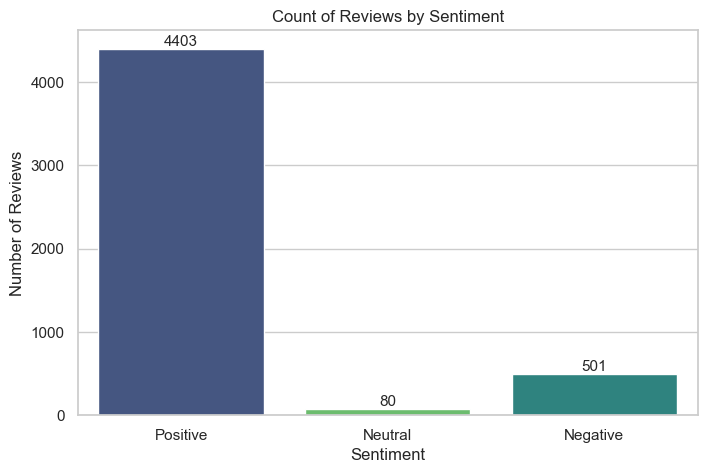

In [6]:
#Task 4 — Visualization

sns.set_theme(style="whitegrid")

#Chart 1 -  Bar chart showing count of Positive, Negative, and Neutral reviews
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=required_df, x='sentiment_label',hue='sentiment_label', palette='viridis', order=['Positive', 'Neutral', 'Negative'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Count of Reviews by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

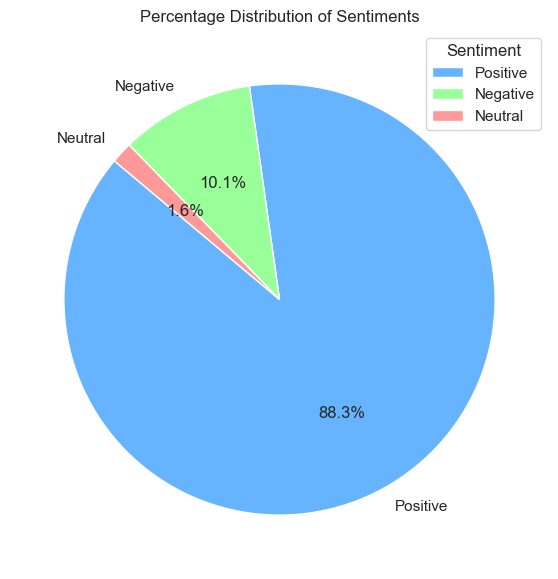

In [7]:
#Task 4 — Visualization

#Chart 2 - Pie chart showing the percentage distribution of sentiments
plt.figure(figsize=(7, 7))
sentiment_counts = required_df['sentiment_label'].value_counts()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ff9999'], startangle=140)
plt.title('Percentage Distribution of Sentiments')
plt.legend(title="Sentiment", loc="best")
plt.show()

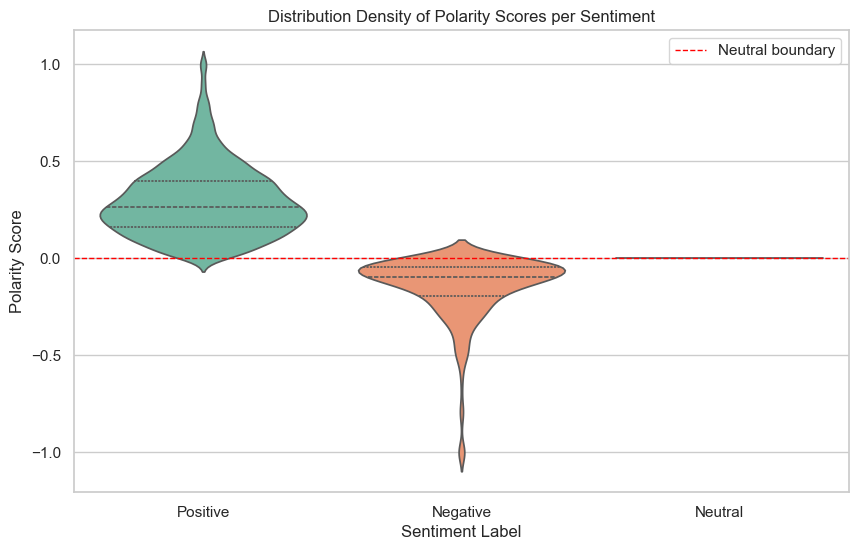

In [8]:
#Task 4 — Visualization

#Chart 3 - Violin plot showing the distribution density of polarity scores per sentiment 
plt.figure(figsize=(10, 6))
sns.violinplot(data=required_df, x='sentiment_label', y='polarity_score',hue='sentiment_label', palette='Set2', inner="quart")
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Neutral boundary')
plt.title('Distribution Density of Polarity Scores per Sentiment')
plt.xlabel('Sentiment Label')
plt.ylabel('Polarity Score')
plt.legend()
plt.show()

In [9]:
#Task 5 — Insights & Summary

#Check sentiment distribution percentages
print("Sentiment Distribution Percentages")
print(required_df['sentiment_label'].value_counts(normalize=True) * 100)
print("\n")

#Check sentiment vs star rating
print("Sentiment Vs Star Rating")
print(pd.crosstab(required_df['Score'], required_df['sentiment_label']))
print("\n")

#Find most common words in negative reviews
print("Most common words in negative reviews")
negative_text = ' '.join(required_df[required_df['sentiment_label'] == 'Negative']['Text'])
words = re.findall(r'\b[a-z]{4,}\b', negative_text.lower())
stopwords = {'this','that','with','from','they','have','just','like','were','your','also','would','been','very','even','when','some','what','than','will','more','much','then'}
filtered = [w for w in words if w not in stopwords]
print(Counter(filtered).most_common(15))
print("\n")

#Check average polarity per star rating
print("Average polarity per rating")
print(required_df.groupby('Score')['polarity_score'].mean().round(3))

Sentiment Distribution Percentages
sentiment_label
Positive    88.342697
Negative    10.052167
Neutral      1.605136
Name: proportion, dtype: float64


Sentiment Vs Star Rating
sentiment_label  Negative  Neutral  Positive
Score                                       
1                     202       17       248
2                      75        6       206
3                      63       10       320
4                      39       11       661
5                     122       36      2968


Most common words in negative reviews
[('these', 190), ('product', 167), ('them', 164), ('taste', 142), ('other', 106), ('food', 101), ('flavor', 96), ('chips', 95), ('only', 89), ('because', 83), ('tried', 73), ('amazon', 73), ('about', 72), ('time', 71), ('which', 66)]


Average polarity per rating
Score
1   -0.012
2    0.088
3    0.162
4    0.245
5    0.308
Name: polarity_score, dtype: float64


# Task 5 — Insights & Summary

Based on my above findings, I hereby answer the following questions.

## 1. What percentage of reviews are positive?
        88.3% of the 5000 reviews are classified as Positive by TextBlob sentiment analysis. This high proportion suggests that customers are largely satisfied with the products they purchase, which is consistent with the behavior seen on platforms like Amazon where satisfied buyers tend to leave more reviews than dissatisfied ones.

## 2. What do customers mostly complain about in negative reviews?
        The most frequent words in negative reviews — taste, flavor, product, chips, food — indicate that complaints are primarily centered around taste and flavor not matching expectations. A secondary concern is delivery and platform experience, evidenced by amazon appearing frequently, suggesting issues with how products arrive (damaged packaging, stale food, wrong items).

## 3. What surprised you in the data?
        The most surprising finding was that 248 out of 467 one-star reviews were classified as Positive by TextBlob — more than half. This exposes a significant limitation: TextBlob scores words in isolation, so a review like "I loved this product but it tasted awful and arrived completely crushed" gets pushed Positive by the word "loved", despite being clearly a negative experience. This means the true negative rate is likely higher than 10%, and a star-rating-aware or context-aware model would be far more accurate for this dataset.

## 4. One recommendation for the business based on your findings
        Since the negative reviews repeatedly highlight taste and flavor disappointment, the business should focus on ensuring product descriptions and images accurately represent taste profiles — particularly for food items like chips and flavored snacks. Misleading descriptions are likely the root cause of the gap between customer expectation and reality. Additionally, since amazon appears in negative reviews, improving packaging to prevent damage during shipping would address the delivery-side complaints.